# Simulate a LIF Network

In this notebook we simulate Hagen's recurrent LIF network using the `ncpi` simulation pipeline. The model scripts are located in `examples/simulation/Hagen_model/simulation/`, with parameters in `params/` and execution code in `python/`.

The default network contains two populations (`E` and `I`; 8192 excitatory + 1024 inhibitory neurons) driven by external Poisson input. We keep all default parameters and only change the external synaptic drive `J_ext` across `28, 30, 32` nA.

Goal: observe how stronger external drive changes collective dynamics, typically producing higher spiking activity and clearer temporal structure in the population response.

At the end, you will visualize:
- spike rasters for each `J_ext`
- time-varying firing-rate traces of `E` and `I` populations

## Requirements

To run this notebook, install:
- `ncpi`
- `nest-simulator` (used by the Hagen model simulation backend)

### 1) Set up paths and imports

This cell imports the required Python packages, locates the repository root automatically, and defines the folders used for Hagen simulations (`params`, `python`, `output`). It also loads the default network and analysis parameters that we will reuse across the sweep.

In [1]:
import os
import sys
import pickle
from copy import deepcopy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import ncpi


def find_repo_root(start_dir: Path) -> Path:
    """Find repo root by locating the Hagen simulation folder."""
    for candidate in [start_dir, *start_dir.parents]:
        if (candidate / "examples" / "simulation" / "Hagen_model" / "simulation").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root containing examples/simulation/Hagen_model/simulation")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
HAGEN_SIM_ROOT = REPO_ROOT / "examples" / "simulation" / "Hagen_model" / "simulation"
PARAM_FOLDER = HAGEN_SIM_ROOT / "params"
PYTHON_FOLDER = HAGEN_SIM_ROOT / "python"
OUTPUT_FOLDER = HAGEN_SIM_ROOT / "output"
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)

if str(PARAM_FOLDER) not in sys.path:
    sys.path.insert(0, str(PARAM_FOLDER))

from network_params import LIF_params as DEFAULT_LIF_PARAMS
from analysis_params import KernelParams

print(f"Repo root: {REPO_ROOT}")
print(f"Simulation root: {HAGEN_SIM_ROOT}")

Repo root: /home/pablomc/OneDrive/2026/ncpi
Simulation root: /home/pablomc/OneDrive/2026/ncpi/examples/simulation/Hagen_model/simulation


### 2) Define helper functions

This cell defines utility functions to load simulation outputs from the latest `ncpi.Simulation` bundle format (`simulation.pkl`) when available, with fallback to the legacy loose pickle files.


In [2]:
def load_simulation_output(output_folder: Path):
    """Load one Hagen LIF simulation output from simulation.pkl or loose pickle files."""
    bundle_file = output_folder / "simulation.pkl"
    if bundle_file.exists():
        with bundle_file.open("rb") as handle:
            payload = pickle.load(handle)

        def first(value):
            if isinstance(value, list):
                return value[0]
            return value

        network = first(payload.get("network"))
        population_sizes = first(payload.get("population_sizes"))
        if population_sizes is None and isinstance(network, dict):
            population_sizes = dict(zip(network.get("X", []), network.get("N_X", [])))

        return {
            "times": first(payload["times"]),
            "gids": first(payload["gids"]),
            "dt": first(payload["dt"]),
            "tstop": first(payload["tstop"]),
            "network": network,
            "population_sizes": population_sizes,
            "bundle_file": bundle_file,
        }

    data = {}
    for name in ["times", "gids", "dt", "tstop", "network"]:
        file_path = output_folder / f"{name}.pkl"
        if file_path.exists():
            with file_path.open("rb") as handle:
                data[name] = pickle.load(handle)

    network = data.get("network")
    if isinstance(network, dict):
        data["population_sizes"] = dict(zip(network.get("X", []), network.get("N_X", [])))
    else:
        data["population_sizes"] = None
    data["bundle_file"] = None
    return data


### 3) Run the `J_ext` sweep and collect results

Here we create an `ncpi.Simulation` object and run three simulations with `J_ext = 28, 30, 32`. After each run, we create the current `simulation.pkl` bundle with `Simulation.bundle_outputs`, load the bundled output, discard the transient period, and store the sweep in `tutorial_lif_spike_sweep.pkl` for downstream tutorials.


In [3]:
# Configure and run the J_ext sweep
J_EXT_VALUES = np.arange(28.0, 34.0, 2.0)
TRANSIENT_MS = float(KernelParams.transient)

sim = ncpi.Simulation(
    param_folder=str(PARAM_FOLDER),
    python_folder=str(PYTHON_FOLDER),
    output_folder=str(OUTPUT_FOLDER),
)

results = []

for j_ext in J_EXT_VALUES:
    lif_params = deepcopy(DEFAULT_LIF_PARAMS)
    lif_params["J_ext"] = float(j_ext)

    # simulation.py reads this file as input network parameters.
    with open(OUTPUT_FOLDER / "network.pkl", "wb") as handle:
        pickle.dump(lif_params, handle)

    print(f"Running simulation with J_ext={j_ext:.0f} nA")
    sim.simulate("simulation.py", "simulation_params.py")
    bundle_path = sim.bundle_outputs(remove_source_files=False)
    print("Bundled latest simulation output:", bundle_path)

    out = load_simulation_output(OUTPUT_FOLDER)
    populations = lif_params["X"]
    population_sizes = out.get("population_sizes") or dict(zip(lif_params["X"], lif_params["N_X"]))

    filtered_times = {}
    filtered_gids = {}

    for pop in populations:
        mask = out["times"][pop] >= TRANSIENT_MS
        filtered_times[pop] = out["times"][pop][mask]
        filtered_gids[pop] = out["gids"][pop][mask]

    results.append(
        {
            "J_ext": float(j_ext),
            "times": filtered_times,
            "gids": filtered_gids,
            "dt": float(out["dt"]),
            "tstop": float(out["tstop"]),
            "transient": TRANSIENT_MS,
            "populations": populations,
            "population_sizes": population_sizes,
            "network": lif_params,
        }
    )

SPIKE_SWEEP_FILE = OUTPUT_FOLDER / "tutorial_lif_spike_sweep.pkl"
spike_payload = {
    "j_ext_values": [float(v) for v in J_EXT_VALUES],
    "records": results,
}
with open(SPIKE_SWEEP_FILE, "wb") as handle:
    pickle.dump(spike_payload, handle)

print("Sweep finished.")
print("Saved sweep file:", SPIKE_SWEEP_FILE)


Running simulation with J_ext=28 nA



              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.8.0
 Built: Jul 24 2025 05:22:32

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.




Jun 02 11:28:07 correlation_detector [Info]: 
    Default for delta_tau changed from 0.03125 to 0.3125 ms

Jun 02 11:28:07 correlomatrix_detector [Info]: 
    Default for delta_tau changed from 0.03125 to 0.3125 ms

Jun 02 11:28:07 correlospinmatrix_detector [Info]: 
    Default for delta_tau changed from 0.00625 to 0.0625 ms

Jun 02 11:28:07 SimulationManager::set_status [Info]: 
    Tics per ms and resolution changed from 1000 tics and 0.1 ms to 16000 tics
    and 0.0625 ms.
Creating population E
 Creating population I
 Connecting E with E 
 

Connecting E with I 
 Connecting I with E 
 Connecting I with I 
 Simulating...
 


Jun 02 11:28:08 NodeManager::prepare_nodes [Info]: 
    Preparing 9472 nodes for simulation.


...

Connecting E with I 
 Connecting I with E 
 Connecting I with I 
 Simulating...
 


Jun 02 11:29:32 NodeManager::prepare_nodes [Info]: 
    Preparing 9472 nodes for simulation.



Jun 02 11:29:32 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 9472
    Simulation time (ms): 12000
    Number of OpenMP threads: 64
    Not using MPI



Jun 02 11:30:23 SimulationManager::run [Info]: 
    Simulation finished.
The simulation took 51.15559792518616 seconds.
 Spike counts: {'E': 1011193, 'I': 220465}; mean population rates Hz: {'E': 10.286387125651041, 'I': 17.941487630208332}; raw spike array bytes: 19706528 (18.79 MiB).


Bundled latest simulation output: /home/pablomc/OneDrive/2026/ncpi/examples/simulation/Hagen_model/simulation/output/simulation.pkl
Sweep finished.
Saved sweep file: /home/pablomc/OneDrive/2026/ncpi/examples/simulation/Hagen_model/simulation/output/tutorial_lif_spike_sweep.pkl


### 4) Plot spike rasters

This cell creates one raster panel per `J_ext` value. For readability, it shows a short time window (`4000` to `4100` ms) and colors E and I spikes differently.

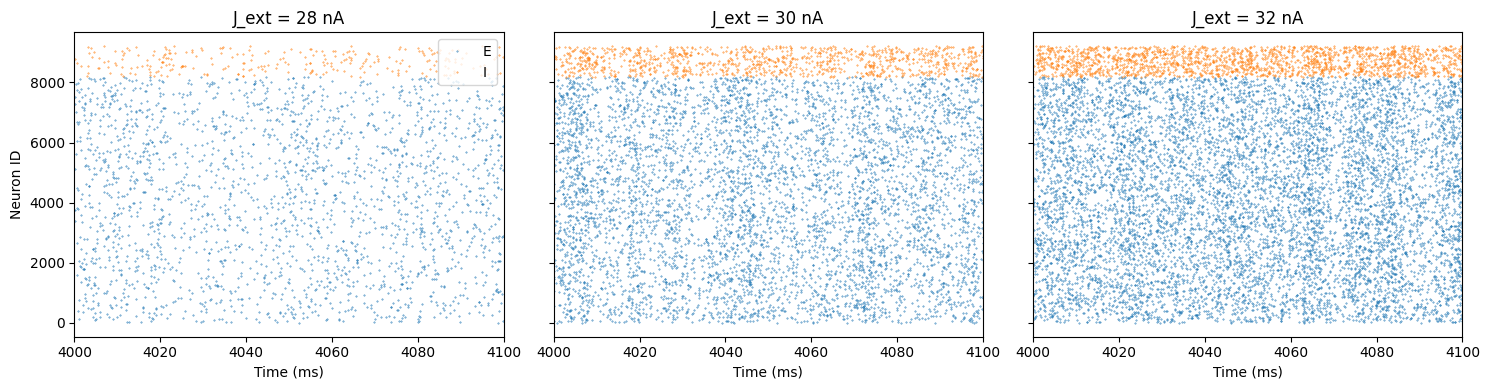

In [4]:
# Spike raster plots (window chosen for readability)
WINDOW_MS = (4000.0, 4100.0)
COLORS = {"E": "#1f77b4", "I": "#ff7f0e"}

fig, axes = plt.subplots(1, len(results), figsize=(5.0 * len(results), 4.0), sharey=True)
if len(results) == 1:
    axes = [axes]

for ax, result in zip(axes, results):
    for pop in result["populations"]:
        t = result["times"][pop]
        g = result["gids"][pop]
        in_window = (t >= WINDOW_MS[0]) & (t <= WINDOW_MS[1])
        ax.plot(
            t[in_window],
            g[in_window],
            ".",
            color=COLORS.get(pop, "k"),
            markersize=0.7,
            label=pop if ax is axes[0] else None,
        )

    ax.set_title(f"J_ext = {result['J_ext']:.0f} nA")
    ax.set_xlabel("Time (ms)")
    ax.set_xlim(WINDOW_MS)

axes[0].set_ylabel("Neuron ID")
axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()

### 5) Plot time-varying firing rates

This final cell computes binned spike counts over time and plots population firing-rate traces (`E` and `I`) in the selected time window for each `J_ext`.

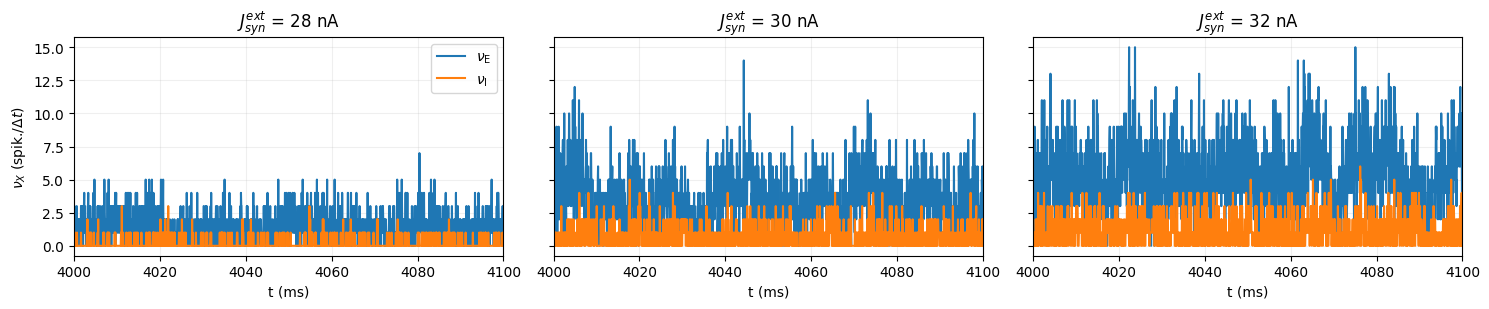

In [5]:
# Time-varying firing rates
def get_spike_rate(times, transient, dt, tstop):
    bins = np.arange(transient, tstop + dt, dt)
    hist, _ = np.histogram(times, bins=bins)
    return bins, hist.astype(float)

T = WINDOW_MS
fig, axes = plt.subplots(1, len(results), figsize=(5.0 * len(results), 3.2), sharey=True)
if len(results) == 1:
    axes = [axes]

for col, (ax, result) in enumerate(zip(axes, results)):
    for i, pop in enumerate(result["populations"]):
        bins, spike_rate = get_spike_rate(
            result["times"][pop],
            result["transient"],
            result["dt"],
            result["tstop"],
        )
        bins = bins[:-1]
        in_window = (bins >= T[0]) & (bins <= T[1])
        ax.plot(
            bins[in_window],
            spike_rate[in_window],
            color=f"C{i}",
            label=rf"$\nu_\mathrm{{{pop}}}$" if col == 0 else None,
        )

    ax.set_title(rf"$J_{{syn}}^{{ext}}$ = {result['J_ext']:.0f} nA")
    ax.set_xlabel("t (ms)")
    ax.set_xlim(T)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel(r"$\nu_X$ (spik./$\Delta t$)")
axes[0].legend(loc="upper right")
plt.tight_layout()
plt.show()